<a href="https://colab.research.google.com/github/sarahmdias19/AI-ML-For-Fluids/blob/main/Lesson_1_3_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A cohort for IA and Fluid Mechanics


# STEP 0. Python Environment Setup (Windows)
!! Virtual Environment
A Python virtual environment has to be created to isolate project dependencies:

1. Install Python 3.12 for Windows.
    https://www.python.org/downloads/release/python-31213/
2. REBOOT your computer

Using Power shell, go to your work directory for this project.
- Create the enviroment in powershell (change the second venv to anything easy to remember):
```bash
python -m venv venv
```
- Environment activation:
```bash
.\venv\Scripts\Activate.ps1
```
- Sometimes it is necessary to change the PowerShell execution policy was updated (user scope only):
```bash
Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
```
## Jupyter / VS Code Kernel
The virtual environment was registered as a Jupyter kernel:
```bash
python -m ipykernel install --user --name venv --display-name "Python (venv)"
```
## Install Packages
The following packages need to be installed inside the virtual environment:
```bash
pip install numpy
pip install matplotlib
pip install tensorflow
```


```python

# =========================================================
# Goal:
# We want the computer to learn this function:
#
#       y = 3x + 2
#
# The real function has:
#
#       weight = 3
#       bias   = 2
#
# But we are NOT going to tell the model directly that
# the answer is 3 and 2.
#
# The model has to learn those values from data.
#
# This is the basic idea of supervised learning:
#
#       input data  ->  correct output data
#
# The model looks at examples and learns the relationship
# between x and y.
# =========================================================

In [1]:
# =========================================================
# Import libraries
# =========================================================

# NumPy is a library for numerical computations.
# We use it to create arrays of numbers and to perform operations
# on many numbers at the same time.
import numpy as np

# TensorFlow is the machine learning library.
# In this example, we use TensorFlow to:
#   - create trainable variables,
#   - compute derivatives automatically,
#   - update the model parameters.
import tensorflow as tf

# Matplotlib is a plotting library.
# We use it to draw the loss curve and the learned function.
import matplotlib.pyplot as plt


```python
# In Python, we can import a library using a shorter name.
#
# For example:
#
#       import numpy as np
#
# means:
#
#       "Import the NumPy library, but call it np in this code."
#
# This is useful because we will use NumPy many times.
# Instead of writing:
#
#       numpy.array(...)
#
# we can write:
#
#       np.array(...)
#
# The shorter name is called an alias.

In [26]:
# ---------------------------------------------------------
# 1. Training data using NumPy
# ---------------------------------------------------------

# We create the input data for training.
#
# np.array(...) creates a NumPy array.
# A NumPy array is similar to a Python list, but it is designed
# for numerical computations.
#
# The values inside the array are the input values x.
# In this example, x goes from -5 to 5.
#
# dtype=np.float32 means that the numbers will be stored as
# 32-bit floating-point numbers.
#
# We use floats because neural networks usually work with
# decimal numbers, not integers.
x_train = np.array(
    [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
    dtype=np.float32
)


# We create the correct output values.
#
# The function we want the model to learn is:
#
#       y = 3x + 2
#
# Since x_train is a NumPy array, Python applies the operation
# to all values at once.
#
# This means that NumPy automatically computes:
#
#       y = 3*(-5) + 2
#       y = 3*(-4) + 2
#       y = 3*(-3) + 2
#       ...
#       y = 3*(5) + 2
#
# So y_train will contain the correct answer for every x value.
y_train = 3 * x_train + 2

In [27]:
# ---------------------------------------------------------
# 2. Create the neural network
# ---------------------------------------------------------

# Here we create a neural network using Keras.
#
# Keras is the high-level API inside TensorFlow.
# It allows us to create neural networks with very little code.
#
# tf.keras.Sequential means that we create a model as a sequence of layers.
#
# In this case, the model has only one layer.
# That layer has only one neuron.
model = tf.keras.Sequential([

    # Dense means "fully connected layer".
    #
    # units=1 means that this layer has one neuron.
    #
    # input_shape=[1] means that the model receives one input value.
    # In this example, the input is only x.
    #
    # A single Dense neuron computes:
    #
    #       prediction = w * x + b
    #
    # where:
    #
    #       w = weight
    #       b = bias
    #
    # During training, the model will learn w and b.
    tf.keras.layers.Dense(units=1, input_shape=[1])
])


In [28]:
# ---------------------------------------------------------
# 3. Tell the model how to learn
# ---------------------------------------------------------

# Before training the model, we need to compile it.
#
# compile() tells the model:
#
#   1. Which optimizer to use.
#   2. Which loss function to use.
#
# The optimizer updates the parameters of the model.
# In this example, the parameters are only:
#
#       w and b
#
# The loss function measures how wrong the model is.
model.compile(

    # SGD means Stochastic Gradient Descent.
    #
    # It is one of the simplest optimizers.
    #
    # The optimizer changes w and b to reduce the error.
    #
    # learning_rate=0.01 controls how large each update is.
    #
    # If the learning rate is too small, learning is very slow.
    # If the learning rate is too large, training can become unstable.
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),

    # mse means Mean Squared Error.
    #
    # It measures the average squared difference between:
    #
    #       the correct value y_train
    #       the predicted value y_pred
    #
    # In mathematical form:
    #
    #       loss = mean((y_true - y_pred)^2)
    #
    # If the loss is large, the model is making bad predictions.
    # If the loss is close to zero, the model is doing well.
    loss="mse"
)


In [29]:
# ---------------------------------------------------------
# 4. Train the model
# ---------------------------------------------------------

# model.fit(...) trains the neural network.
#
# This is where the model learns w and b.
#
# We give the model:
#
#       x_train -> input values
#       y_train -> correct output values
#
# The model tries to find values of w and b such that:
#
#       w*x + b
#
# is close to:
#
#       3x + 2
history = model.fit(

    # Input data.
    x_train,

    # Correct output data.
    y_train,

    # epochs is the number of training repetitions.
    #
    # One epoch means that the model goes through the training data once.
    #
    # Here, the model will repeat the learning process 500 times.
    epochs=500,

    # verbose=0 means that Keras will not print the training progress
    # at every epoch.
    #
    # If you use verbose=1, Keras will print a progress bar.
    verbose=0
)

# The variable "history" stores information about the training process.
#
# For example, it stores the loss value at each epoch.
# We will use it later to plot the training loss.


In [30]:
# ---------------------------------------------------------
# 5. Look at what the model has learned
# ---------------------------------------------------------

# The model has one layer:
#
#       model.layers[0]
#
# That layer has trainable parameters:
#
#       w and b
#
# get_weights() returns those learned parameters.
w, b = model.layers[0].get_weights()

# We print the learned values.
print("\nLearned parameters:")

# w is stored as a small matrix.
#
# Since we have:
#
#       one input
#       one output neuron
#
# the weight is inside w[0][0].
print("w =", w[0][0])

# b is stored as a small array.
#
# Since we have only one neuron, the bias is inside b[0].
print("b =", b[0])

# We print the expected values.
#
# Since the real function is:
#
#       y = 3x + 2
#
# the model should learn:
#
#       w ≈ 3
#       b ≈ 2
print("\nExpected:")
print("w = 3")
print("b = 2")


Learned parameters:
w = 2.9999995
b = 1.999918

Expected:
w = 3
b = 2


In [32]:
# ---------------------------------------------------------
# 6. Test the model
# ---------------------------------------------------------

# Now we test the model with a new value.
#
# We choose:
#
#       x = 10
#
# The correct answer should be:
#
#       y = 3*10 + 2 = 32
#
# We use a NumPy array because Keras models expect input data
# in array-like format.
x_new = np.array([10.0])

# model.predict(...) uses the trained model to make a prediction.
#
# It computes:
#
#       prediction = learned_w * x_new + learned_b
prediction = model.predict(x_new)

# We print the prediction made by the model.
print("\nPrediction for x = 10:")

# prediction is also stored as an array.
# Since we only predicted one value, we access it with prediction[0][0].
print("Model prediction:", prediction[0][0])

# We also print the correct answer.
print("Correct answer:", 3 * 10 + 2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Prediction for x = 10:
Model prediction: 31.999914
Correct answer: 32


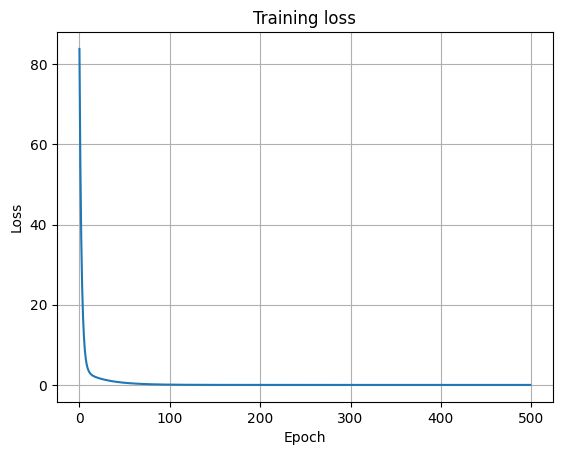

In [33]:
# ---------------------------------------------------------
# 7. Plot the training loss
# ---------------------------------------------------------

# We create a new figure.
plt.figure()

# history.history["loss"] contains the loss value at each epoch.
#
# If training works well, the loss should go down.
plt.plot(history.history["loss"])

# Label for the horizontal axis.
plt.xlabel("Epoch")

# Label for the vertical axis.
plt.ylabel("Loss")

# Title of the plot.
plt.title("Training loss")

# Add a grid to make the plot easier to read.
plt.grid(True)

# Show the plot.
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


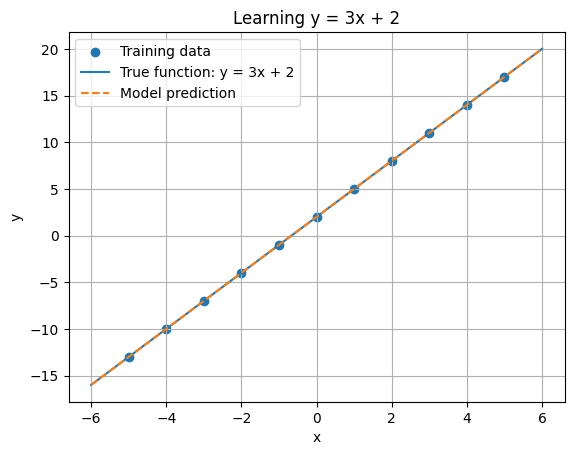

In [34]:

# ---------------------------------------------------------
# 8. Plot the learned function
# ---------------------------------------------------------

# We create many x values between -6 and 6.
#
# np.linspace(-6, 6, 100) creates 100 equally spaced values.
#
# These values are used only for plotting a smooth line.
x_plot = np.linspace(-6, 6, 100)

# These are the true y values from the real function:
#
#       y = 3x + 2
y_true = 3 * x_plot + 2

# These are the y values predicted by the trained model.
#
# The model uses the learned values of w and b.
y_pred = model.predict(x_plot)

# Create a new figure.
plt.figure()

# Plot the original training data as points.
#
# scatter means that we draw individual points.
plt.scatter(x_train, y_train, label="Training data")

# Plot the true function as a continuous line.
plt.plot(x_plot, y_true, label="True function: y = 3x + 2")

# Plot the model prediction as a dashed line.
#
# "--" means dashed line.
plt.plot(x_plot, y_pred, "--", label="Model prediction")

# Label for the horizontal axis.
plt.xlabel("x")

# Label for the vertical axis.
plt.ylabel("y")

# Show the legend.
# The legend explains what each line or set of points means.
plt.legend()

# Add a grid.
plt.grid(True)

# Add a title.
plt.title("Learning y = 3x + 2")

# Show the plot.
plt.show()

After enough training, increasing the number of epochs may not improve the result much.